# Module 2: Hydrostatics 

In [1]:
!pip install handcalcs -q
!pip install Pillow -q

In [2]:
import handcalcs.render
from sympy import symbols, Eq, solve
from math import sqrt,pi, cos, sin, radians,asin,atan,degrees, tan, log10
from PIL import Image

Global variables:

In [3]:
%%render param
g=9.81 #m/s2
rho_water=1000 #kg/m3
rho_Hg=13600 #kg/m3
p_atm=101325 #Pa

<IPython.core.display.Latex object>

## Problems for Lecture 4: Viscosity

### Viscosity

---
#### Question 1 (*)

A square block has a contact area of 0.02 m<sup>2 </sup>  with a table that is lubricated with a 0.1 mm thick layer of oil with viscosity 7 mPa.s. What force is required to move the block at a constant velocity of 1 m/s?

```{dropdown} Answer
$1.4 \; N$
```

```{dropdown} Hint

Since the block moves at constant velocity, the net forces in this problem is zero:

$$
F-\tau A=0\\
$$

$$
\tau = \mu \frac {\Delta V}{\Delta y}
$$
```

**Solution**

```{dropdown} Show code cell outputs

Since the block moves at constant velocity, the net forces in this problem is zero:

$$
\sum F=0\\
$$

this means the applied force must balance the force caused by the oil's viscosity:

$$
F-\tau A=0\\
$$

where:

- $F$ is the force required to move the block.
- $A$ is the contact area.
- $\tau$ is the shear stress, which according to Newton´s viscosity law, can be expressed as the absolute viscosity ($\mu$) multiplied by the rate of change of velocity ($\frac {\Delta V}{\Delta y}$):

$$
\tau = \mu \frac {\Delta V}{\Delta y}
$$
```

In [4]:
%%render long 4
A=0.02 #m2
y=0.1 #mm 
mu_oil=7*10**-3 #Pa.s
Delta_V= 1 #m/s


Delta_y= y/1000 #m

tau= mu_oil*(Delta_V/Delta_y) #Pa

F= tau*A #N

<IPython.core.display.Latex object>

---
#### Question 2 (**)[R]

A space 16 mm wide between two large plane surfaces is filled with oil with a viscosity μ = 0.18 N.s/m<sup>2</sup>. What force F will be required to drag a very thin plate of 0.4 m<sup>2</sup> area between the surfaces at a speed of 0.25 m/s if the plate is positioned 5 mm from the bottom surface?

```{dropdown} Answer
$5.24 \; N$
```

```{dropdown} Hint
The sum of forces in this problem is equal to zero since at a constant velocity:

$$
F-\tau A=0\\
$$

$$
\tau = \mu \frac {\Delta V}{\Delta y}
$$

```

**Solution**

```{dropdown} Show code cell outputs
The sum of forces in this problem is equal to zero since at a constant velocity, aceleration is zero:

$$
\sum F=0\\
$$

The sum of forces can be express as follows:

$$
F-\tau A=0\\
$$

where:

- $F$ is the force required to drag the plate.
- $A$ is the contact area.
- $\tau$ is the shear stress, which according to Newton´s viscosity law, can be expressed as the absolute viscosity ($\mu$) multiplied by the rate of change of velocity ($\frac {\Delta V}{\Delta y}$):

$$
\tau = \mu \frac {\Delta V}{\Delta y}
$$

The total force requiered to drag the plate is the sum of the force of the oil and the force of the plate:

$$
F=F_{oil}+F_{plate}
$$

where the forces of the oil and the plate can be expressed as follows:

$$
F_{oil}= \mu\frac{dV}{(y_{oil}-y_{plate})} A\\
$$

$$
F_{plate}= \mu\frac{dV}{dy} A
$$
```

In [5]:
%%render long 3
mu=0.18 #N.s/m2
V=0.25 #m/s
yplate=5/1000 #m
yoil=16/1000 #m
A=0.4 #m2

y_foil= yoil-yplate #m
tau_oil= mu*(V/y_foil) #N/m2
tau_plate= mu*(V/yplate) #N/m2
F_oil= tau_oil*A #N
F_plate= tau_plate*A #N
F= F_oil+F_plate #N

<IPython.core.display.Latex object>

---
#### Question 3 (**)

A space 10 mm wide between two large plane surfaces is filled with oil with viscosity μ = 0.18 N.s/m<sup>2</sup>. A very thin plate with a 0.5 m<sup>2</sup> area is located halfway between the two surfaces. If a constant force of 10 N is applied the plate, at what speed will it be dragged out from between the surfaces?

```{dropdown} Answer
$0.278 \; m/s$
```

```{dropdown} Hint
Assuming the plate reaches a steady-state while being dragged out from between the surfaces, the applied force equals to viscosity:

$$
F=A\tau\\
$$

$$
\tau = \mu \frac {\Delta V}{\Delta y}
$$

Since the plate is halfway between the two surfaces, it experiences shear stress from both oil layers. Therefore, the total Area is $1m^2$ because the area of one plate is $A= 0.5 m^2$ and $\Delta y$ is half of the distance between the plane surfaces

```

**Solution**

```{dropdown} Show code cell outputs
Assuming the plate reaches a steady-state while being dragged out from between the surfaces, the applied force equals to viscosity:

$$
F=A\tau\\
$$

where:

- $F$ is the force required to drag the plate.
- $A$ is the contact area.
- $\tau$ is the shear stress, which according to Newton´s viscosity law, can be expressed as the absolute viscosity ($\mu$) multiplied by the rate of change of velocity ($\frac {\Delta V}{\Delta y}$):

$$
\tau = \mu \frac {\Delta V}{\Delta y}
$$

Since the plate is halfway between the two surfaces, it experiences shear stress from both oil layers. Therefore, the total Area is $1m^2$ because the area of one plate is $A= 0.5 m^2$ and $\Delta y$ is half of the distance between the plane surfaces

Solving for $\Delta v$ we have:

$$
F=A \mu \frac {\Delta V}{\Delta y}\\
\Delta V =F\frac {\Delta y}{\mu A_{total}}
$$


```

In [6]:
%%render long 3
A=0.5 #m2
L=10/1000 #m
mu =0.18 #N.s/m2
F= 10 #N

L= L/2 #m
A_total= A*2 #m2
V= F*L/(mu*A_total) #m/s

<IPython.core.display.Latex object>

---
#### Question 4 (**)[R]

 A square block weighing 1.1 kN and with side lengths of 250 mm slides down a 20 °  incline on a film of oil 6.0 micrometre thick. Assuming a linear velocity profile in the oil, what is the terminal velocity of the block? The viscosity of the oil is 7 mPa.s.

```{dropdown} Answer
$5.16 \; m/s$
```

```{dropdown} Hint
At terminal velocity, the block is moving at a constant speed, meaning the net force acting on it is zero. By considering the forces along each axis, the following equation can be derived:

$$
F_\mu-Wsin\theta=0\\
$$


The force can also be expressed using the Newton´s viscosity law as follows:

$$
F_\mu=\tau A\\
$$

```

**Solution**

```{dropdown} Show code cell outputs
At terminal velocity, the block is moving at a constant speed, meaning the net force acting on it is zero. By considering the forces along an inclined plane, the following equation can be derived:

$$
\sum F_x=0\\
$$

$$
F_\mu-Wsin\theta=0\\
$$

$$
F_\mu=Wsin\theta\\
$$

The force can also be expressed using the Newton´s viscosity law as follows:

$$
F_\mu=\tau A\\
$$

$$
F_\mu=\mu \frac{dV}{dy} A\\
$$

Now, equating both expressions, we have:

$$
\mu \frac{dV}{dy} A=Wsin\theta\\
$$
```

In [7]:
%%render long 6
W=1.1*10**3 #N
theta=20 #°
dy=6*10**-6 #m
mu=7*10**-3 #Pa.s
L=250/1000 #m

A= L**2 #m2
dV= (W*sin(radians(theta))*dy)/(A*mu) #m/s

<IPython.core.display.Latex object>

---
#### Question 5 (***)

 A hydraulic lift consist of a 280 mm diameter ram which slides in a 280.18 mm  cylinder, the annular space being filled with oil having a kinematic viscosity of 0.00042 m<sup>2</sup>/s and a specific gravity of 0.86. If the rate of travel of the ram is 0.22 m/s, find the frictional resistance when 2 m of the ram is engaged in the cylinder.

```{dropdown} Answer
$1553 \; N$
```

```{dropdown} Hint
The frition resistance is caused by the viscous shear stress acting on the ram due to the oil, and it can be calculated as $F=\tau A$  

From Newton's law of viscosity, shear stress is
$\tau = \mu \frac {\Delta V}{\Delta y}$ 

```

**Solution**

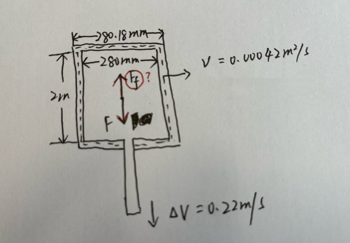

In [8]:
from PIL import Image
img = Image.open(r"figures/viscosity_5.jpg")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
The frition resistance is caused by the viscous shear stress acting on the ram due to the oil, and it can be calculated as $F=\tau A$  

where:  

- $A=h \cdot \pi \cdot d_{lift}$ which is the area of the cylinder  
- $\tau = \mu \frac {\Delta V}{\Delta y}$ using the Newton’s law of viscosity  

The dynamic viscosity can be calculated as $\mu = \nu \cdot \rho$

where:  

- $\rho = s \cdot \rho_{water}$  

```

In [9]:
%%render long 5
d_lift= 280/1000 #m
d_cyl=280.18/1000 #m
nu= 0.00042 #m2/s
s=0.86 
Delta_V=0.22 #m/s
h=2 #m

rho= s*rho_water #kg/m3
mu= nu*rho #Pa.s
Delta_y= (d_cyl-d_lift)/2 #m

tau= mu*Delta_V/(Delta_y) #Pa
A= h*pi*d_lift #m2
F= tau*A #N

<IPython.core.display.Latex object>

---
#### Question 6 (***)

A piston with diameter of 127 mm, height 152 mm and weight 93.4 N slides free in a lubricated vertical pipe. The clearance between the piston and the pipe is 0.0254 mm. If the piston decelerates at 0.64 m/s<sup>2</sup> when its speed is 6.4 m/s, what is the viscosity of the oil?

```{dropdown} Answer
$0.0065 \; N.s/m^2$
```

```{dropdown} Hint
In this case, since there is a deceleration, the sum of forces along the axis must be set equal to mass times acceleration. Including all the forces in the equation, we have the following

Newton's Second Law：

$$
\sum F=ma\\
F_\tau - W=ma\\
$$

the Newton’s law of viscosity:

$$
F_\tau=\mu \frac{dV}{dy} A\\
$$

```

**Solution**

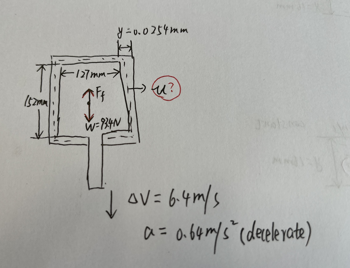

In [10]:
from PIL import Image
img = Image.open(r"figures/viscosity_6.jpg")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
In this case, since there is a deceleration, the sum of forces along the axis must be set equal to mass times acceleration. Including all the forces in the equation, we have the following

$$
\sum F=ma\\
F_\tau - W=ma\\
$$

where $F_\tau$ can be expressed as follows, using the Newton’s law of viscosity:

$$
F_\tau=\mu \frac{dV}{dy} A\\
$$

Now, replacing the equation that expresses $F_\tau$ in the sum of forces, we obtain the following:

$$
\mu \frac{dV}{dy} A - W =ma
$$
```

In [11]:
%%render long 7
d=127/1000 #m
h=152/1000 #m
W=93.4 #N
dy=0.0254/1000 #m
dV=6.4 #m/s
a=0.64 #m/s2

A= 2*pi*(d/2)*h #m2
m= W/g #kg

mu= ((m*a+W)/(A*dV))*dy #N.s/m2

<IPython.core.display.Latex object>

---
#### Question 7 (***)

A journal bearing consists of an 80.0 mm diameter shaft in an 80.4 mm sleeve 120 mm long. The clearance space is filled with oil with a viscosity of 0.11 N.s/m<sup>2</sup>. Calculate the torque required to keep the shaft turning at 150 rpm.

```{dropdown} Answer
$0.417 \; N.m$
```

```{dropdown} Hint

The torque is calculated by multiplying the force with the distance

$$
T= F \cdot r_{journal}\\
$$

where the force can be calculated as follows:

$$
F=\tau A\\
$$

according to Newton's Law of Viscositiy:

$$
\tau= \mu\frac {\Delta V}{\Delta y}
$$

```

**Solution**

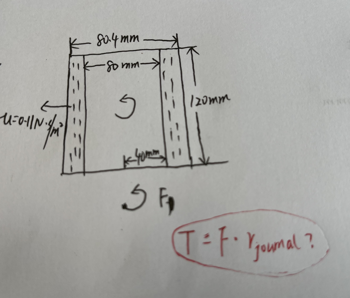

In [12]:
from PIL import Image
img = Image.open(r"figures/viscosity_7.jpg")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

The torque is calculated by multiplying the force with the distance

$$
T= F \cdot r_{journal}\\
$$

where the force can be calculated as follows:

$$
F=\tau A\\
$$

where:

- $F$ is the force.
- $A$ is the contact area.
- $\tau$ is the shear stress, which according to Newton´s viscosity law, can be expressed as the absolute viscosity ($\mu$) multiplied by the rate of change of velocity ($\frac {\Delta V}{\Delta y}$):

$$
\tau= \mu\frac {\Delta V}{\Delta y}
$$

In the equation the velocity needs to be in m/s. For that reason, the units have to be converted: 

$$
V= wr
$$

$$
w= \frac {2 \pi N}{60}
$$

$$
V=\frac{r_{journal}\cdot2\cdot\pi\cdot N_{rpm}}{60}
$$

Replacing the expressions, we have the following equation:  

$$
T= F \cdot r_{journal}\\  
T= \tau A \cdot r_{journal}\\  
T= \mu\frac {\Delta V}{\Delta y} A \cdot r_{journal}\\  
T= \mu\frac {\frac{r_{journal}\cdot2\cdot\pi\cdot N_{rpm}}{60}}{\Delta y} A \cdot r_{journal}\\
$$

```

In [13]:
%%render long 4
d_journal= 80/1000 #m
d_sleeve= 80.4/1000 #m
long_sleeve= 120/1000 #m
mu_filled=0.11 #Ns/m2
N_rpm=150 #rpm

r_journal= (d_journal)/2 #m

V= (r_journal*2*pi*N_rpm)/60 #m/s

Delta_y= ((d_sleeve-d_journal))/2 #m

tau= mu_filled*V/Delta_y #Pa

F= tau*pi*(d_journal)*(long_sleeve) #N

T= F*r_journal #N.m


<IPython.core.display.Latex object>

## Problems for Lecture 5: Introduction to Hydrostatics

### Absolute Pressure, Gauge Pressure and Pressure  Head

---
#### Question 1 (*)[R]

The weather report states that the current atmospheric pressure is 970 mbar. 

a) Express the pressure as an absolute pressure measured in Pa. 

b) Express the pressure as an absolute pressure head of water.   

c) Express the pressure as a absolute pressure head of mercury (assume the density of mercury to be 13 600 kg/m<sup>3</sup>).

```{dropdown} Answer
$
a) \; 97 \; kPa
$

$
b) \; 9.89 \; m 
$

$
c) \; 0.73 \; m 
$
```


**Question 1 (a)**


```{dropdown} Hint
Consider the following unit conversions:  

$$ p[bar]=p[mbar]*10^{-3}$$  
$$ p[kPa]=p[bar]*100$$  
$$ p[Pa]=p[kPa]*1000$$  
```

**Solution**

In [14]:
%%render long 2
p_mbar=970 #mbar
p_bar= p_mbar*10**-3 #bar
p_kPa= p_bar*100 #kPa
p_Pa= p_kPa*1000 #Pa

<IPython.core.display.Latex object>

**Question 1 (b)**

```{dropdown} Hint
The head of water can be calculated with the hydrostatic pressure equation:

$$
p= \rho_{Water}  \cdot g \cdot h 
$$
```

**Solution**

```{dropdown} Show code cell outputs
The head of water can be calculated with the hydrostatic pressure equation:

$$
p= \rho_{Water}  \cdot g \cdot h 
$$

where 
- $p$  = hydrostatic pressure [$Pa$]
- $\rho$ = density of the fluid [$kg/m^3$]
- $g$ = gravitational acceleration [$m/s^2$]
- $h$ = height of the fluid column [$m$]

Solving for $h$:

$$h=\frac{p}{\rho_{water} \cdot g}$$
```

In [15]:
%%render long 2
h_water= p_Pa/(rho_water*g) #m

<IPython.core.display.Latex object>

**Question 1 (c)**

```{dropdown} Hint
The absolute pressure head of mercury can be calulated with the hydrostatic pressure equation, using the density of mercury:  

$$
p= \rho_{Hg} \cdot g \cdot h 
$$

$$h=\frac{p}{\rho_{Hg} \cdot g}$$
```

**Solution**

In [16]:
%%render long 2
h_Hg= p_Pa/(rho_Hg*g) #m

<IPython.core.display.Latex object>

---
#### Question 2(*)

 If the pressure in a tank is 500 kPa. Find the equivalent pressure head of a) water b) mercury with density 13 600 kg/m<sup>3</sup> and c) heavy fuel oil with a specific gravity of 0.92. 

```{dropdown} Answer
$
a) \; 51 \; m
$

$
b) \; 3.7 \; m 
$

$
c) \; 55.4 \; m 
$
```


**Question 2 (a)**

```{dropdown} Hint
The head of water can be calculated with the hydrostatic pressure equation:

$$
p= \rho \cdot g \cdot h 
$$
```

**Solution**

```{dropdown} Show code cell outputs
The head of water can be calculated with the hydrostatic pressure equation:

$$
p= \rho \cdot g \cdot h 
$$

where 
- $p$  = hydrostatic pressure [$Pa$]
- $\rho$ = density of the fluid [$kg/m^3$]
- $g$ = gravitational acceleration [$m/s^2$]
- $h$ = height of the fluid column [$m$]

Considering the above equation, the units of $p$ should be change from [kPa] to [Pa]. Solving for $h$:

$$h=\frac{p}{\rho_{water} \cdot g}$$
```

In [17]:
%%render long 2
p=500 #kPa
rho_Hg_=13600 #kg/m3
s=0.92
p_Pa=p*1000 #Pa
h_water= p_Pa/(g*rho_water) #m

<IPython.core.display.Latex object>

**Question 2 (b)**

**Solution**

In [18]:
%%render long 2
h_Hg= p_Pa/(g*rho_Hg_) #m

<IPython.core.display.Latex object>

**Question 2 (c)**


```{dropdown} Hint

The specific gravity ($s$) is the ratio of the fluid’s density to the density of water:

$$
s= \frac {\rho_{oil}}{\rho_{water}}
$$

By using the equation of specific gravity the $\rho_{oil}$ can be calculated assuming a $ \rho_{water}=1000 kg/m^3$
```

**Solution**

In [19]:
%%render long 2
rho_oil= s*rho_water #kg/m3
h_oil= p_Pa/(g*rho_oil) #m

<IPython.core.display.Latex object>

---
#### Question 3 (**)[R]

If the atmospheric pressure is 780 mbar and a gauge attached to a tank reads 330 mm Hg vacuum, what is the absolute pressure within the tank? Assume s<sub>Hg</sub> = 13.56.

```{dropdown} Answer
$
34 \; kPa
$
```


```{dropdown} Hint
The absolute pressure can be calculated as 

$$
p_{abs}=p_{atm}-p_{vacuum}
$$  

The $p_{vacuum}$ is the difference between atmospheric pressure and the actual pressure inside the tank. It measures how much lower the internal pressure is compared to atmospheric pressure. 

```

**Solution**

```{dropdown} Show code cells outputs
The absolute pressure can be calculated as 

$$
p_{abs}=p_{atm}-p_{vacuum}
$$  

The $p_{vacuum}$ is the difference between atmospheric pressure and the actual pressure inside the tank. It measures how much lower the internal pressure is compared to atmospheric pressure. 

$p_{atm}$ is given and $p_{vacuum}$ can be calculated with the hydrostatic pressure equation: 

$$
p_{vacuum}=\rho \cdot g \cdot h
$$  

Remember that the specific gravity ($s$) is the ratio of the fluid’s density to the density of water:

$$
s= \frac {\rho_{Hg}}{\rho_{water}}
$$

By using the equation of specific gravity the $\rho_{Hg}$ can be calculated assuming a $ \rho_{water}=1000 kg/m^3$

```

In [20]:
%%render long 2
s_Hg=13.56
h=330/1000 #m
p_atm_=78000 #Pa
rho_Hg= s_Hg*rho_water #kg/m3
p_vacuum= rho_Hg*g*h #Pa
p_abs= p_atm_-p_vacuum#Pa
p_abs_kPa= p_abs/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 4 (***)

A pressure gauge is connected to a tank filled with fluid under standard sea level conditions. The gauge shows a reading of 305 kPa. The gauge is then enclosed in a chamber as shown below, and the absolute pressure head in the chamber reduced to 100 mm Hg (the fluid pressure remains unchanged). What will the reading on the pressure gauge now be?

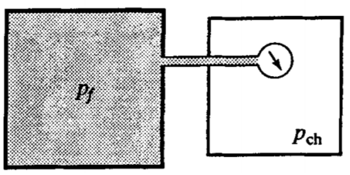

In [21]:
from PIL import Image
img = Image.open(r"figures/30.png")
base_width = 350 # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$
393 \; kPa
$
```


```{dropdown} Hint
The absolute pressure can be calculates as 

$$
p_{abs}= p_{atm}+ p_{gauge}
$$ 

The pressure inside the chamber now is 100 mmHg, so with this a new atmospheric pressure can be calculated. To calculate the pressure in the chamber considering the height of the fluid the hydrostatic equation should be used.

```

**Solution**

```{dropdown} Show code cells outputs
The absolute pressure can be calculates as 

$$
p_{abs}= p_{atm}+ p_{gauge}
$$ 

The units of the three pressure should be in [Pa]. For that reason, a unit conversion must be done for $p_{gauge}$ 

The pressure inside the chamber now is 100 mmHg, so with this a new atmospheric pressure can be calculated. To calculate the pressure in the chamber considering the height of the fluid the hydrostatic equation should be used:

$$p_{chamber}=\rho \cdot g \cdot h_{Hg}$$

where the units are  $p=[Pa], \rho=[kg/m^3], g= [m/s^2], h_{Hg}=[m]$

For that reason, a unit conversion must be done for $h_{Hg}$

A gauge pressure is the difference between the absolute pressure in the tank and the absolute pressure in the surrounding chamber

$$
p_{gauge2}= p_{abs}-p_{chamber}
$$ 

```

In [22]:
%%render long 1
p_gauge= 305 #kPa
h_Hg= 100 #mmHg 
p_gauge_Pa= p_gauge*1000 #Pa
p_abs= p_atm+p_gauge_Pa#Pa
h_Hg= h_Hg/1000 #m
p_chamber= rho_Hg*g*h_Hg #Pa
p_gauge_2= p_abs-p_chamber #Pa
p_gauge2_kPa= p_gauge_2/1000 #kPa

<IPython.core.display.Latex object>

### Pressure Variation in Incompressible Fluids

---
#### Question 5 (*)

Calculate the gauge and absolute pressures at a depth of 10 m below a water surface under standard sea level conditions.

```{dropdown} Answer
$
98.1 \; kPa \; ; 199.4 \; kPa
$
```


```{dropdown} Hint
The atmospheric pressure under standard sea level conditions is 101325 Pa and the gauge pressure can be calculated with the hydrostatic pressure equation as

$$
p_{gauge}=\rho_{water} \cdot g \cdot h
$$  


Having the atmospheric pressure and the gauge pressure, the absolute pressure can be calculated using the equation:

$$p_{abs}= p_{atm}+ p_{gauge}$$
```

**Solution**

```{dropdown} Show code cells outputs
The atmospheric pressure under standard sea level conditions is 101325 Pa and the gauge pressure can be calculated with the hydrostatic pressure equation as

$$
p_{gauge}=\rho_{water} \cdot g \cdot h
$$  


Having the atmospheric pressure and the gauge pressure, the absolute pressure can be calculated using the equation:

$$p_{abs}= p_{atm}+ p_{gauge}$$
```

In [23]:
%%render long 1
h= 10 #m
p_gauge= rho_water*g*h #Pa
p_gauge_kPa= p_gauge/1000 #kPa
p_abs= (p_atm+p_gauge)/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 6 (*)[R]

The pressure vessel below contains glycerine to a depth of 2 m under pressure as shown. Find the pressure at the bottom of the tank.

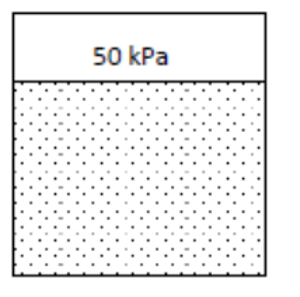

In [24]:
from PIL import Image
img = Image.open(r"figures/32.png")
base_width = 300  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$
74.68 \; kPa
$
```


```{dropdown} Hint

The glycerine density can be found in a table of physical properties.

To calculate the pressure at the bottom of the tank $p_{bottom}$, add the pressure at the top of the glycerine column and the pressure due to the glycerine.

$$p_{bottom}= p_{top}+p_{glycerine}$$
```

**Solution**

```{dropdown} Show code cell outputs

The fisrt step is refer to a table of physical properties of common liquids at standard sea-level atmospheric pressure to find the density of glycerine. $\rho_{glycerine} =1258 kg/m^3$

To calculate the pressure of the glycerine the hydrostatic pressure equation should be used:  

$$p_{glycerine}=\rho_{glycerine} \cdot g \cdot h$$ 

where the units are $p=[Pa],\rho=[kg/m^3], g= [m/s^2], h=[m]$. 

To calculate the pressure at the bottom of the tank $p_{bottom}$, add the pressure at the top of the glycerine column and the pressure due to the glycerine

$$p_{bottom}= p_{top}+p_{glycerine}$$
```

In [25]:
%%render long 2
h = 2 #m
p_top=50 #kPa
rho_glycerine=1258 #kg/m3
p_top_Pa= p_top*1000 #Pa
p_bottom= p_top_Pa+rho_glycerine*g*h #Pa
p_bottom_kPa= p_bottom/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 7 (**)[R]

An open tank contains 10 m of water, covered with 1 m of oil with s = 0.80. Find the absolute pressure at (a) the interface between the two fluids and (b) the bottom of the tank. 

```{dropdown} Answer
$
a) \; 109.1 \; kPa
$

$
b)\; 207.2 \; kPa
$
```


**Question 7 (a)**

```{dropdown} Hint
The absolute pressure can be calculated as 

$$ p_{abs}= p_{atm}+ p_{gauge}$$

Since the tank is open to the atmosphere, the atmospheric pressure can be assumed as standard sea-level atmospheric pressure.
```

**Solution**

```{dropdown} Show code cell outputs
The absolute pressure can be calculated as 

$$ p_{abs}= p_{atm}+ p_{gauge}$$

Since the tank is open to the atmosphere, the atmospheric pressure can be assumed as 101325 Pa (standard sea-level atmospheric pressure).

The gauge pressure at the interface between the two fluids is given by the hydrostatic pressure equation as 

$$p_{gauge}=\rho_{oil} \cdot g \cdot h_{oil}$$

The density of the oil can be determined using its specific gravity as $\rho_{oil}=s_{oil} \cdot \rho_{water}$
```

In [26]:
%%render long 2
h_water= 10 #m
h_oil= 1 #m
s_oil= 0.8
rho_oil= s_oil*rho_water #kg/m3
p_abs1= p_atm+rho_oil*g*h_oil #Pa
p_abs1_= p_abs1/1000 #kPa

<IPython.core.display.Latex object>

**Question 7 (b)**

```{dropdown} Hint

The absolute pressure at the bottom of the tank can be calculated as the sum of the absoulte pressure at the interface of the fluids and the gauge pressure at the bottom of the tank.
```

**Solution**

```{dropdown} Show code cell outputs

The absolute pressure at the bottom of the tank can be calculated as the sum of the absoulte pressure at the interface of the fluids and the gauge pressure at the bottom of the tank. That is: 

$$p_{abs2}= p_{abs1}+ p_{gauge}$$

The gauge pressure at the bottom of the tank can be calculated as 

$$p_{gauge}=\rho_{water} \cdot g \cdot h_{water}$$
```

In [27]:
%%render long 2
p_abs2= p_abs1+rho_water*g*h_water #Pa
p_abs2_= p_abs2/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 8 (**)

A pressure gauge at an elevation 4.8 m on the side of a storage tank containing oil reads 34.7 kPa. Another gauge at elevation 2.2 m reads 57.5 kPa. Calculate the specific weight, density and specific gravity of the oil. 

```{dropdown} Answer
$
8.77 \; kN/m^3 \; ; \; 894 kg/m^3 \; ; \; 0.894
$
```


```{dropdown} Hint

The equation for pressure variation in a static fluid is:

$$ 
\Delta p = \rho \cdot g \cdot h 
$$
```

**Solution**

```{dropdown} Hint

The equation for pressure variation in a static fluid is:

$$ 
\Delta p = \rho \cdot g \cdot h 
$$

where 
- $\Delta p$ is the pressure differente between two points (Pa)
- $\rho$ is the density of the fluid ($kg/m^3)
- $\Delta h$ is the elevation differente between two points (m)

The pressure difference can be calculated as:

$$
\Delta p= p_{gauge2}-p_{gauge1}
$$

The elevation difference is:

$$
\Delta h= h_1-h_2
$$

The next step is calculate the specific weight, density and specific gravity of the oil with the following equations: 

$$
\rho=\frac {\Delta p}{ g \cdot \Delta h}
$$

$$
\gamma=\rho \cdot g
$$

$$
s= \frac {\gamma}{\gamma_{water}}
$$

The units of the variables are: $\gamma= [N/m^3], p= [Pa], h= [m], g = [m/s^2], \rho =[kg/m^3]$
```

In [28]:
%%render long 3
h_1=4.8 #m
p_gauge_1= 34.7 #kPa
h_2=2.2 #m
p_gauge_2= 57.5 #kPa
Delta_p= (p_gauge_2-p_gauge_1)*1000 #Pa
Delta_h= h_1-h_2 #m
rho_oil= Delta_p/(g*Delta_h) #kg/m3
gamma_oil= rho_oil*g/1000 #kN/m3
s_oil= rho_oil/(rho_water) 

<IPython.core.display.Latex object>

---
#### Question 9 (**)

A closed vessel containing oil with a density of 830 kg/m<sup>3</sup> under pressure is shown below. The space above the oil is pressurised to 35 kPa above atmospheric pressure. Find the elevation of the oil surface in the attached tube. 

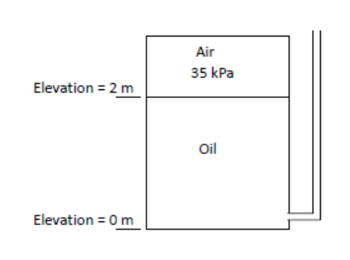

In [29]:
from PIL import Image
img = Image.open(r"figures/35.png")
base_width =  350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
$
6.3 \; m
$
```


```{dropdown} Hint


- Consider $p_1$ at the oil-air interface inside the closed tank (elevation of 2 m) 
- Consider $p_2$ at the same horizontal level in the attached tube (unkowing h). 

Points at the same height within the same fluid experience equal pressure.
```

**Solution**

```{dropdown} Show code cell outputs


- Consider $p_1$ at the oil-air interface inside the closed tank (elevation of 2 m) 
- Consider $p_2$ at the same horizontal level in the attached tube (unkowing h). 

Since these points are at the same height in the same fluid (oil), they must have equal pressure. Thus, the pressure at $p_1$ (inside the tank) must be the same as the pressure at $p_2$ (in the tube). 

Inside the tank the $p_1$ is given by the exercise, and $p_2$ can be calculated using the hydrostatic pressure equation 

$$p_2 = \rho \cdot g \cdot h_2$$

Considering the pressures are the same we have 

$$
p_1= \rho \cdot g \cdot h_2
$$

And the total elevation of the oil is the sum between the elevation in the tube $h_2$ and the elevation given in the exercise $h_1$

$$
h_{oil}=h_1+h_2
$$
```

In [30]:
%%render long 1
rho_oil=830 #kg/m3
h_1=2 #m
p_1=35000 #Pa
h_2= p_1/(rho_oil*g) #m
h_oil= h_1+h_2 #m

<IPython.core.display.Latex object>

---
#### Question 10 (**)[R]

Calculate the level h of the oil in the right-hand tube in the figure below.

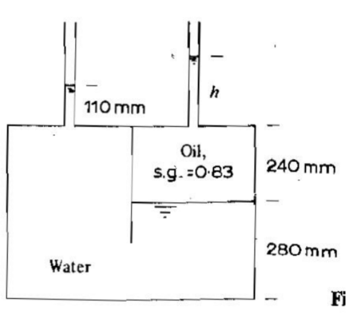

In [31]:
from IPython.display import display, HTML
img = Image.open(r"figures/36.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img 

```{dropdown} Answer
$
182 \; mm
$
```


```{dropdown} Hint
Points at the same height within the same fluid experience equal pressure.

The pressure can be calculates using the hydrostatic pressure equation:

$$
p= \rho \cdot g \cdot h 
$$
```

**Solution**

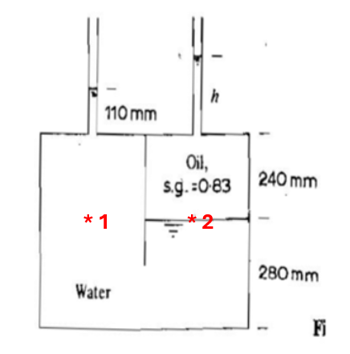

In [32]:
from PIL import Image
img = Image.open(r"figures/36S.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
The pressure in $p_1$ and $p_2$ are the same because is the same fluid in the same height. Considering the pressure can be calculated with the hydrostatic pressure equation $p=\rho \cdot g \cdot h$

The pressure in points 2 and 1 can be calculated as:

$$
p_2 = \rho_{oil} \cdot g \cdot (h+h_{oil}) \\
$$

$$
p_1= \rho_{water} \cdot  g \cdot (h_{oil}+h_{tube})\\
$$

The pressure in point 1 can be calculated because all the variables are given. Once this value has been calculated, the nex step is equalizing both pressures

$$
\rho_{oil} \cdot g \cdot (h+h_{oil})= p_1\\
$$

$$
h= \frac {p_1}{\rho _{oil} \cdot g} -h_{oil}
$$
```

In [33]:
%%render long 1
s=0.83 
h_oil =240 #mm
h_tube=110 #mm
h_water=280 #mm
rho_oil = s*rho_water
p_1= (h_tube+h_oil)*10**-3*g*rho_water #Pa
h= p_1/(rho_oil*g)-(h_oil*10**-3) #m
h_mm= h*1000 #mm

<IPython.core.display.Latex object>

---
#### Question 11 (**)

An open tube is attached to a tank as shown below. If the water rises to a height of 800 mm in the tube, what are the pressures pA and pB of the air above the water? Neglect capillary effects. 

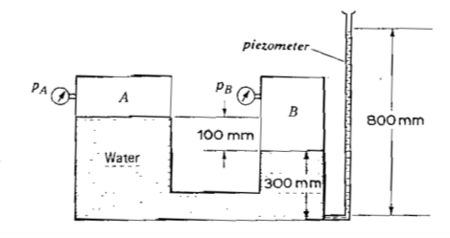

In [34]:
from PIL import Image
img = Image.open(r"figures/37.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img 

```{dropdown} Answer
$
3.92 \; kPa \; ; \; 4.91 \; kPa
$
```


```{dropdown} Hint
Points at the same height within the same fluid experience equal pressure.

The pressure can be calculates using the hydrostatic pressure equation:

$$
p= \rho \cdot g \cdot h 
$$
```

**Solution**

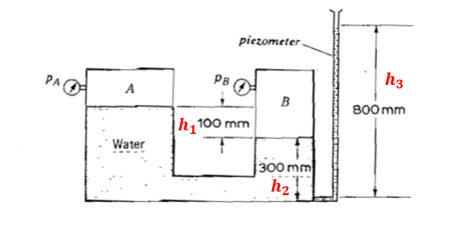

In [35]:
from PIL import Image
img = Image.open(r"figures/37S.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img 

```{dropdown} Show code cell outputs
The pressure can be calculated with the hydrostatic pressure equation:  $p=\rho_{water} \cdot g \cdot h$ 

At point A, $h$ is equal to $h_3-h_2-h_1$, with that the pressure for point A is:

$$
p_A=\rho_{water} \cdot g \cdot (h_3-h_2-h_1)
$$

and at point B, $h$ is equal to $h_3-h_2$, with that the pressure for point B is:

$$
p_B=\rho_{water} \cdot g \cdot (h_3-h_2)
$$

Note that to convert the pressures from Pa to kPa, the pressures need to be divided by 1000.
```

In [36]:
%%render long 2
h_1= 100*10**-3 #m
h_2= 300*10**-3 #m
h_3=800*10**-3 #m
p_A= (rho_water*g*(h_3-h_2-h_1))/1000 #kPa
p_B= (rho_water*g*(h_3-h_2))/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 12 (***)

A submarine is situated 1000 m below sea level. The pressure inside the submarine is controlled. If water inside the submarine boils at a temperature of 90°C, what is the pressure difference between the inside and outside of the submarine? Take the density of sea water as 1 023 kg/m<sup>3</sup>. 

```{dropdown} Answer
$
10.1 \; MPa
$
```


```{dropdown} Hint
For the pressure difference the following equation has to be used: 

$$
\Delta p= p_{out} - p_{in}
$$

The pressure inside the submarine can be determined using the boiling point of water. 
```

**Solution**

```{dropdown} Show code cell outputs
For the pressure difference the following equation has to be used: 

$$
\Delta p= p_{out} - p_{in}
$$

The pressure outside the submarine can be calculated as the sum of the atmospheric pressure at sea level and the pressure due to the water column above the submarine, using the hydrostatic pressure equation.  

$$
p_{out}=p_{atm} + \rho_{seawater} \cdot g \cdot h
$$ 


The pressure inside the submarine can be determined using the boiling point of water from standard reference tables. $p_{in}=p_v= 70.1 kPa$

```

In [37]:
%%render long 1
h=1000 #m
rho_sea_water=1023 #kg/m3
p_out= (p_atm + rho_sea_water*g*h)/1000  #kPa
p_v=70.1 #kPa
Delta_p= (p_out-p_v)/1000 #MPa

<IPython.core.display.Latex object>

## Problems for Lecture 6: Manometry

### Piezometers

---
#### Question 1 (*)

A piezometer is attached to the top of a pressure vessel with a pressure of 25 kPa. If the vessel is filled with a fluid that has a specific gravity of 1.85, how high would the fluid rise in the piezometer?

```{dropdown} Answer

$1.38 \; m$
```

```{dropdown} Hint
Use the hydrostatic pressure equation:

$$
p= \rho_{fluid} \cdot g \cdot h\\
$$

```

**Solution**

```{dropdown} Show code cell outputs
The height in the piezometer can be solved from the hydrostatic pressure equation:

$$
p= \rho_{fluid} \cdot g \cdot h\\
h=\frac{p}{\rho_{fluid} \cdot g}
$$  

where:
- $p$ is the pressure of the fluid.
- $\rho_{fluid}$ is the density of the fluid, which can be calculated using the specific gravity: $\rho_{fluid}=s_{fluid} \cdot \rho_{water}$
- $g$ is the gravity.
- $h$ is the height of the fluid.

```

In [38]:
%%render long 2
p=25000 #Pa
s_fluid=1.85
rho_fluid= s_fluid*rho_water #kg/m3
h= p/(rho_fluid*g) #m

<IPython.core.display.Latex object>

---
#### Question 2 (**)

An open tank has two piezometers attached to its side as shown below. The tank contains two immiscible (non-mixing) liquids. Find the a) elevation of the liquid surface in piezometer A, b) elevation of the liquid surface in piezometer B and c) the pressure at the bottom of the tank.

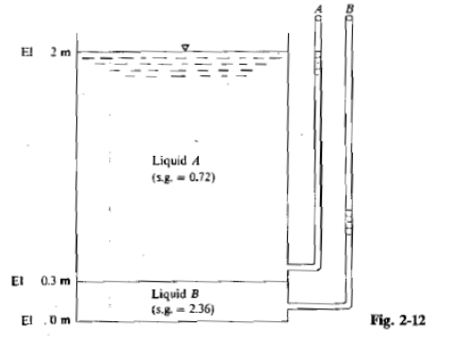

In [39]:
from PIL import Image
img = Image.open(r"figures/40.png")
base_width = 450  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img 

```{dropdown} Answer

a) $2 \; m$  
b) $0.82 \; m$  
c) $18.9 \; kPa$  

```

**Question 2 (a)**

**Solution**

```{dropdown} Show code cell outputs
The liquid A will simply rise in piezometer A to the same elevation as liquid A in the tank (2 m)
```

**Question 2 (b)**

```{dropdown} Hint

Use the hydrostatic pressure equation:

$$
p= \rho \cdot g \cdot h\\
$$


```

**Solution**

```{dropdown} Hint

The height in the piezometer B can be solved from the hydrostatic pressure equation:

$$
p_B= \rho_{B} \cdot g \cdot h\\
h=\frac{p_B}{\rho_{B} \cdot g}
$$  

where:
- $p$ is the pressure of the fluid.
- $\rho_{B}$ is the density of the fluid, which can be calculated using the specific gravity: $\rho_{B}= s_{B} \cdot \rho_{water}$
- $g$ is the gravity.
- $h$ is the height of the fluid.


$p_B$ can be calculated considering that the pressure of $p_A$ is igual to $p_B$ at the interface of the two liquids. 

The pressure of the Liquid A can be calculated using the hydrostatic pressure equation $p_A=\rho_A \cdot g \cdot h_A$. Considering that $h_A$ is the height of the Liquid A, which is the difference between the total height of the tank and the height of the liquid B.


```

In [40]:
%%render long 2
h_t=2 #m
h_B=0.3 #m
s_A=0.72 
s_B=2.36
h_A= h_t-h_B #m

rho_A=s_A*rho_water # kg/m3
p_A= rho_A*g*(h_A) #Pa
p_B=p_A #Pa
rho_B= s_B*g*rho_water #kg/m3
h= p_B/(rho_B) #m
h_liquid_b= h_B+h #m

<IPython.core.display.Latex object>

**Question (c)**

```{dropdown} Hint
The pressure at the bottom is the sum of the pressure exerted by Liquid A and Liquid B
```

**Solution**

In [41]:
%%render long 2
p_bottom = (s_A*g*(h_A))+s_B*g*h_B #kPa


<IPython.core.display.Latex object>

### Barometers

---
#### Question 3(*)

What is the atmospheric pressure if a mercury barometer reads 742 mm? Work from basic principles. Assume &rho;<sub>Hg</sub> = 13 600 kg/m<sup>3</sup>.

```{dropdown} Answer

$99 \; kPa$ 

```

```{dropdown} Hint

Use the hydrostatic pressure equation:

$$
p= \rho \cdot g \cdot h\\
$$


```

**Solution**

```{dropdown} Show code cell outputs

Pressure can be calculated with the hydrostatic pressure equation:

$$
p= \rho_{fluid} \cdot g \cdot h
$$  

where:
- $p$ is the pressure of the fluid.
- $\rho_{fluid}$ is the density of the fluid, which in this problem corresponds to the density of mercury.
- $g$ is the gravity.
- $h$ is the height read in the barometer.
```

In [42]:
%%render long 1
h=0.742 #m
rho_Hg_=13600 #kg/m3

p= rho_Hg_*g*h #Pa
p_kPa= p/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 4 (**)

A scientist plans to build a water barometer. When the atmospheric pressure is 990 mb abs and the water temperature 70°C, what would you expect the barometer reading to be?

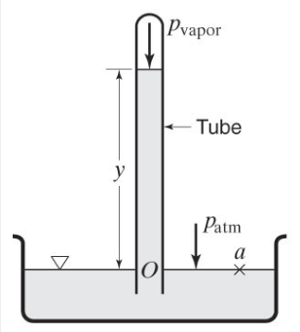

In [43]:
from PIL import Image
img = Image.open(r"figures/42.png")
base_width = 300  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$7.07 \; m$ 

```

```{dropdown} Hint
According to the image of the barometer, atmospheric pressure is the sum of the vapor pressure of the liquid and the pressure of the liquid.
```

**Solution**

```{dropdown} Show code cell outputs

According to the image of the barometer, atmospheric pressure is the sum of the vapor pressure of the liquid and the pressure of the liquid. Using the hydrostatic pressure equation, this can be expressed as:

$$
p_{atm}= p_v+\rho_{liquid} \cdot g \cdot h
$$  

or in therms of the specific weight: 

$$
p_{atm}= p_v+\gamma_{liquid} \cdot h
$$ 

The specific weight and the saturation vapor presure head at 70°C can be found in the Physical properties of water at standard sea-level atmospheric pressure table.

```

In [44]:
%%render long 2
p_atm_ex= 990 #mb
gamma= 9.589 #kN/m3
p_v= 31.16 #kN/m2
p_atm_kPa= p_atm_ex*0.1 #kPa
h_barom= p_atm_kPa/gamma-p_v/gamma #m

<IPython.core.display.Latex object>

---
#### Question 5 (***)

A mercury barometer has a reading of 750 mm. Sketch this scenario and work from basic principles to calculate the atmospheric pressure. What is the impact on the reading of ignoring Mercury’s vapour pressure? Assume &rho;<sub>Hg</sub> = 13 550 kg/m<sup>3</sup>.

```{dropdown} Answer
 
 $99.69 \; kPa \;; 0.0002 \; \% \; ; negligible$

```

```{dropdown} Hint

Use the hydrostatic pressure equation:

$$
p= \rho \cdot g \cdot h\\
$$ 

  
Also, the effect of ignoring the vapor pressure of mercury can be calculated as the fraction that the vapour pressure represents in the atmosferic pressure.

```

**Solution**

```{dropdown} Show code cell outputs

The atmosferic pressure is equal to the sum of the vapour pressure of mercury and the gauge pressure read in the barometer, which using the hydrostatic pressure equation can be expressed as:

$$ p_{atm}=p_{vHg}+(\rho_{Hg} \cdot g \cdot h) $$   

  
The effect of ignoring the vapor pressure of mercury can be calculated as the fraction that the vapour pressure represents in the atmosferic pressure:  

$$ Effect_{Hg}=\frac{p_{vHg}}{p_{atm}} $$  

The vapor pressure of mercury can be found in the Physical properties of common liquids at standard sea-level atmospheric pressure table.

```

In [45]:
%%render long 4

h=0.75 #m
rho_Hg_=13550 #kg/m3

p_vHg=0.17 #N/m2
p_atm_= p_vHg+(rho_Hg_*g*h) #Pa
p_atm__= p_atm_/1000 #kPa
Effect_Hg= (0.17/p_atm_)*100 #%

<IPython.core.display.Latex object>

### Manometers

---
#### Question 6 (**)[R]

A manometer is attached to a water tank as shown below. Find the height of the free water surface above the bottom of the tank. Work from basic principles. Assume ρ<sub>Hg</sub> = 13 600 kg/m<sup>3</sup>.

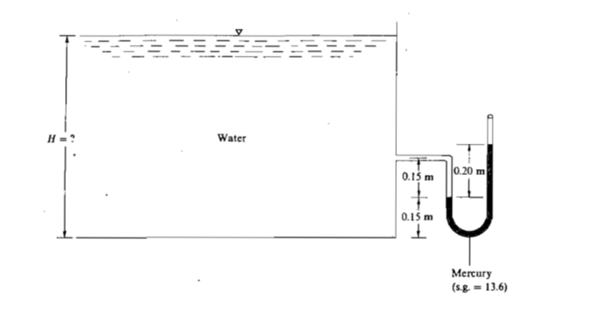

In [46]:
from PIL import Image
img = Image.open(r"figures/44.png")
base_width = 600  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$2.87 \; m$ 

```

```{dropdown} Hint

Use the hydrostatic pressure equation:

$$
p= \rho \cdot g \cdot h\\
$$


```

**Solution**

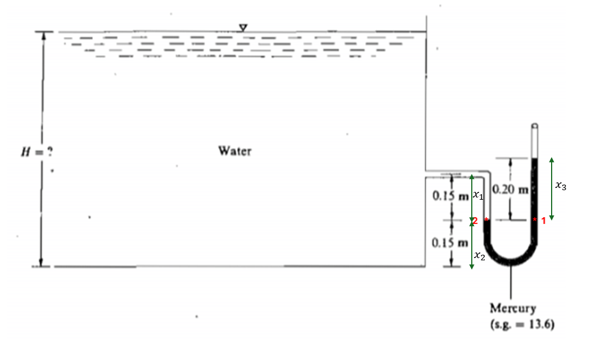

In [47]:
from PIL import Image
img = Image.open(r"figures/44s.png")
base_width = 600  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs

With the hydrostatic pressure equation, $p_1$ and $p_2$ can be expressed as:  

$$
p_1 = \rho_{Hg} \cdot  g \cdot x_3\\
$$

$$
p_2 = \rho_{water} \cdot g \cdot x_1 + \rho_{water} \cdot g \cdot (H-x_1 -x_2)\\
$$

Simplyfing $p_2$:

$$
p_2 = \rho_{water} \cdot g \cdot (H-x_2)
$$

Finally, $p_1 =p_2 $ because they are on the same level and same fluid, therefore, we can equate the equations:

$$
\rho_{water} \cdot g \cdot (H-x_2)=\rho_{Hg} \cdot g \cdot x_3 \\
$$
```


In [48]:
%%render long 2

rho_Hg_= 13600 #kg/m3
x_1=0.15 #m
x_2= 0.15 #m
x_3= 0.20 #m

H= (rho_Hg_*g*x_3)/(rho_water*g)+x_2 #m

<IPython.core.display.Latex object>

---
#### Question 7 (**)[R]

Calculate the difference in manometer mercury levels (y) in the figure below from basic principles. Assume ρ<sub>Hg</sub> = 13 600 kg/m<sup>3</sup>.

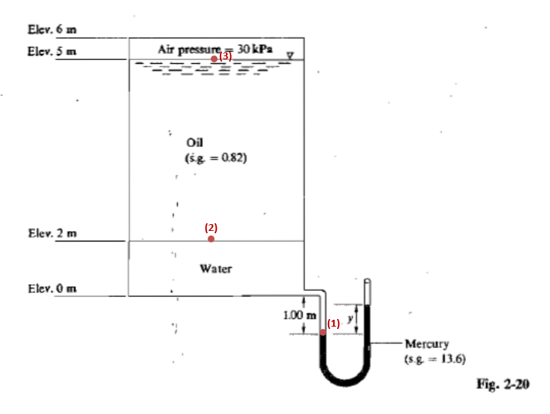

In [49]:
from PIL import Image
img = Image.open(r"figures/45.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$626 \; mm$ 

```

```{dropdown} Hint

The pressure is the same at the same level and the same fluid.

```

**Solution**

```{dropdown} Show code cell outputs

The pressure corresponding to height 'y' is equal to the pressure at (1) because it is the same level and the same fluid. Therefore, this height can be calcuated with the hydrostatic pressure equation as:  

$$y=\frac{p_1}{\rho_{Hg} \cdot g}$$  

For that reason, it is necessary to calculate $p_1$. To do this, the following process can be developed:

The first step is to calculate the pressure at (2), which is equal to the sum of the pressure at (3) and the pressure of the oil from (3) to (2):  

$$p_2=p_3+\rho_{oil} \cdot g \cdot (h_3-h_2)$$  

Once the pressure in the point 2 is calculated, it is possible to determine the pressure in point 1 because $p_1$ is equal to the sum of the pressure at (2) and the pressure of the water from (2) to (1):  

$$p_1=p_2+\rho_{water} \cdot g \cdot (h_2+h_1)$$  

Remember that the density of the oil can be calculated as:$\rho_{oil}=s_{oil} \cdot \rho_{oil}$

```

In [50]:
%%render long 2

rho_Hg_=13600 #kg/m3
s_oil=0.82
h_1=1 #m
h_2=2 #m
h_3=5 #m
h_4=6 #m
p_3=30000 #Pa

rho_oil= s_oil*rho_water #kg/m3
p_2= p_3+rho_oil*g*(h_3-h_2) #Pa
p_1= p_2+rho_water*g*(h_2+(h_1)) #Pa
y= p_1/(rho_Hg_*g) #m
y_mm= y*1000 #mm


<IPython.core.display.Latex object>

---
#### Question 8 (**)

Calculate the pressure pa in the figure below if the specific gravity of the oil is 0.82. Assume ρ<sub>Hg</sub> = 13 600 kg/m<sup>3</sup>

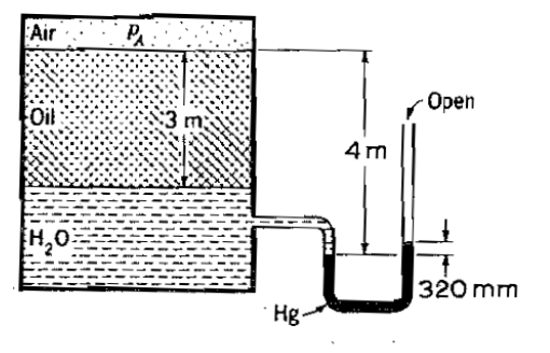

In [51]:
from PIL import Image
img = Image.open(r"figures/46.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$8.7 \; kPa$ 

```

```{dropdown} Hint

The pressure is the same at the same level and the same fluid.

```

**Solution**

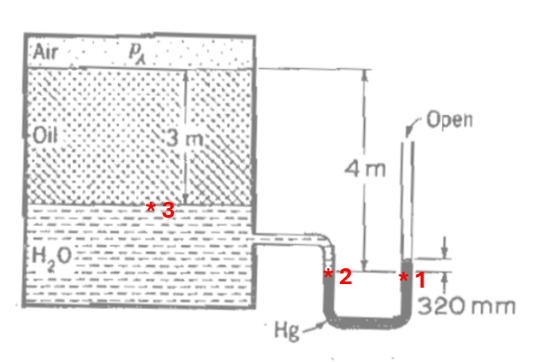

In [52]:
img2 = Image.open(r"figures/46s.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img2.size[0])
h_size = int(float(img2.size[1]) * w_percent)
resized_img = img2.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
Pressure in 1 and 2 is the same because is a constant static fluid. 

$$p_1= p_2 $$

Using the hydrostatic pressure equation, $p_1$, $p_2$, and $p_3$ can be expressed as follows:

$$
p_1= \rho_{Hg} g y_{man} \\
$$

$$
p3=p_A + \rho_{oil} \cdot g \cdot y_{oil}\\
$$

$$
p_2= p_3+ \rho_{water} \cdot g \cdot (y_{oil_{water}}-y_{oil})
$$

Using the three equations $p_A$ can be solved as:

$$
p_A=-\rho_{oil} \cdot g \cdot y_{oil}+p_3\\
p_3=-\rho_{water} \cdot g \cdot (y_{oil_{water}}-y_{oil})+p_2\\
p_A=-\rho_{oil} \cdot g \cdot y_{oil}-\rho_{water} \cdot g \cdot (y_{oil_{water}}-y_{oil})+p_2\\
p_2=\rho_{Hg} g y_{man} \\
p_A=-\rho_{oil} \cdot g \cdot y_{oil}-\rho_{water} \cdot g \cdot (y_{oil_{water}}-y_{oil})+\rho_{Hg} g y_{man}\\
$$

```

In [53]:
%%render long 2

rho_Hg_= 13600 #kg/m3
s_oil= 0.82
y_oil= 3 #m
y_man= 320 #mm
y_oil_water= 4 #m 

rho_oil=s_oil*rho_water # kg/m3
p_A= -(rho_oil*g*y_oil)-g*rho_water*(y_oil_water-y_oil)+rho_Hg_*g*y_man/1000 #Pa

<IPython.core.display.Latex object>

---
#### Question 9 $(*)$ $(**) $ $(***)$

A mercury manometer is used to measure the pressure in a vessel containing water as shown in the figure below. The following measurements were taken:  
$h_1$ = 300mm and $h_2$ = 150mm.  

a.* What was the pressure in the vessel at its center (point A) based on the measured values?  
b.** If the diameter of the pressure vessel is 2m, what is the pressure at its bottom?  
c.*** It is later discovered that an air bubble with an effective height of 10 mm was trapped in the water of the left leg of the manometer when the readings were taken. Calculate the corrected pressure in the container if this bubble is taken into consideration.


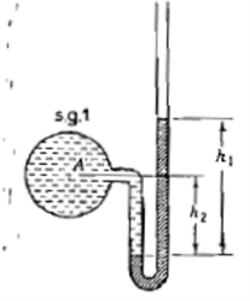

In [54]:
from PIL import Image
img = Image.open(r"figures/47.png")
base_width = 250  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer
 
 a) $38.4 \; kPa$  
 b) $48.2 \; kPa$  
 c) $38.5 \; kPa$  
 
```

**Question 9 (a)**

```{dropdown} Hint

Consider that the pressure is the same at the same level in the same fluid and the hydrostatic pressure equation.
```

**Solution**

```{dropdown} Show code cell outputs

Considering that the pressure is the same at the same level in the same fluid and the hydrostatic pressure equation, we have the following expression:  

$$
p_A+\rho_{water} \cdot g \cdot h_2=\rho_{Hg} \cdot g \cdot h_1
$$

Therefore, solving for $p_A$:  

$$
p_A=\rho_{Hg} \cdot g \cdot h_1-\rho_{water} \cdot g \cdot h_2
$$


Note: the Mercury's density can be assumed as $\rho_{Hg}=13550 kg/m^3$
```

In [55]:
%%render long 2

h_1=0.3 #m
h_2=0.15 #m
d=2 #m
h_bubble=0.01 #m

rho_Hg_= 13550 #kg/m3
p_A= rho_Hg_*g*h_1-rho_water*g*h_2 #Pa
p_A_= p_A/1000 #kPa

<IPython.core.display.Latex object>

**Question 9 (b)**

**Solution**

```{dropdown} Show code cell outputs
The pressure at the bottom is equal to the pressure at A plus the pressure from point A to the bottom. This can be expressed as the following equation:  

$$p_{bottom}=p_{A}+\rho_{water} \cdot g \cdot \frac{d}{2}$$

```

In [56]:
%%render long 2
p_bottom= p_A+rho_water*g*(d/2) #Pa
p_bottom_= p_bottom/1000 #kPa

<IPython.core.display.Latex object>

**Question 9 (c)**

**Solution**

```{dropdown} Show code cell outputs
The bubble reduces the height of the water by 10mm, therefore the pressure in the container is:  

$$
p_A=\rho_{Hg} \cdot g \cdot h_1-\rho_{water} \cdot g \cdot (h_2-h_{bubble})
$$
```

In [57]:
%%render long 2
p_A= rho_Hg_*g*h_1-rho_water*g*(h_2-h_bubble) #Pa
p_A_= p_A/1000 #kPa

<IPython.core.display.Latex object>

---
#### Question 10 (**)[R]

What is the pressure difference between points A and B in the system below? Work from basic principles. Assume ρ<sub>Hg</sub> = 13550 kg/m<sup>3</sup>.

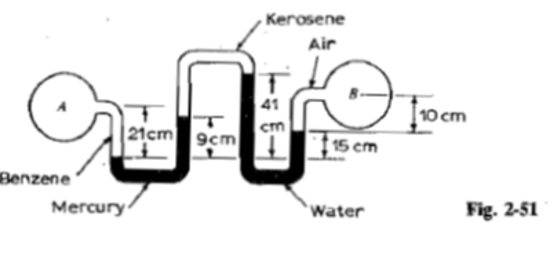

In [58]:
from PIL import Image
img = Image.open(r"figures/48.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$10.1 \; kPa$ 

```

```{dropdown} Hint
Considering that the same fluid at the same height has the same pressure, the following points have equal pressures 
$p_1=p_2, p_3=p_4, p_5=p_6$. 

```

**Solution**

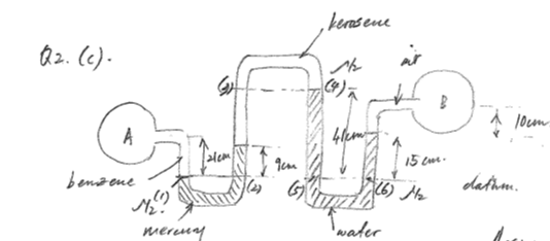

In [59]:
from PIL import Image
img = Image.open(r"figures/48s.png")
base_width = 550  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
Considering that the same fluid at the same height has the same pressure, the following points have equal pressures 
$p_1=p_2, p_3=p_4, p_5=p_6$. 

Furthermore, taking into account that the pressure is greater when a point is lower, that is, the pressures should be added.For exmaple, the pressure in point 1 is higher than the pressure in A. For that reason, $p_1=p_A + \rho_{benz} \cdot g  \cdot y_{benz}$

Considering the points of equal pressure and the statement explained previously, the following equations can be obtained.

$$
p_1=p_A + \rho_{benz} \cdot g \cdot y_{benz}\\
$$

$$
p_3=p_1-\rho_{Hg} \cdot g \cdot y_{Hg}-\rho_{kero} \cdot g \cdot (y_{water_1}-y_{Hg})\\
$$

$$
p_5= p_4 + \rho_{water} \cdot g \cdot y_{water_1}\\
$$

$$
p_B=p_6-\rho_{water} \cdot g \cdot h_{kero}-\rho_{air} \cdot g \cdot y_{air}
$$

The pressure diference between A and B all can be obtained with the previous equations:

$$
\Delta _{p_{AB}}= p_A-p_B\\
= p_1-\rho_{benz} \cdot g \cdot y_{benz}-p_6-\rho_{water} \cdot g \cdot h_{kero}-\rho_{air} \cdot g \cdot y_{air}\\
= p_3+\rho_{Hg} \cdot g \cdot y_{Hg}+\rho_{kero} \cdot g \cdot (y_{water_1}-y_{Hg})-\rho_{benz} \cdot g \cdot y_{benz}-p_6-\rho_{water} \cdot g \cdot h_{kero}-\rho_{air} \cdot g \cdot y_{air}\\
=p_4+\rho_{Hg} \cdot g \cdot y_{Hg}+\rho_{kero} \cdot g \cdot (y_{water_1}-y_{Hg})-\rho_{benz} \cdot g \cdot y_{benz}-p_5-\rho_{water} \cdot g \cdot h_{kero}-\rho_{air} \cdot g \cdot y_{air}\\
=p_4+\rho_{Hg} \cdot g \cdot y_{Hg}+\rho_{kero} \cdot g \cdot (y_{water_1}-y_{Hg})-\rho_{benz} \cdot g \cdot y_{benz}-p_4-\rho_{water} \cdot g \cdot y_{water_1}-\rho_{water} \cdot g \cdot h_{kero}-\rho_{air} \cdot g \cdot y_{air}\\
=\rho_{Hg} \cdot g \cdot y_{Hg}+\rho_{kero} \cdot g \cdot (y_{water_1}-y_{Hg})-\rho_{benz} \cdot g \cdot y_{benz}-\rho_{water} \cdot g \cdot y_{water_1}-\rho_{water} \cdot g \cdot h_{kero}-\rho_{air} \cdot g \cdot y_{air}\\
$$


```

In [60]:
%%render long 2
rho_Hg_= 13550 #kg/m3
rho_benz=876 #kg/m3
rho_kero= 808 #kg/m3
rho_air=1.22 #kg/m3
y_benz= 21 #cm 
y_Hg= 9 #cm 
y_water1= 41 #cm 
y_air= 10 #cm 
y_water2= 15 #cm 

Delta_p_AB= -rho_benz*g*y_benz/100 +rho_Hg_*g*y_Hg/100+rho_kero*g*(y_water1-y_Hg)/100 -rho_water*g*y_water1/100+rho_water*g*y_water2/100+rho_air*g*y_air/100 #Pa

<IPython.core.display.Latex object>

### Inverted Manometers

---
#### Question 11 (***)

In the figure below, the liquid at A and B is water and the manometer liquid is oil with s = 0.80, h<sub>1</sub> = 300 mm, h<sub>2</sub> = 200 mm, and h<sub>3</sub> = 600 mm. a) Determine the difference between the pressures at A and B. b) if pB = 50 kPa and the barometer reading is 730 mm Hg, find the absolute pressure head at A in meters of water. Assume ρ<sub>Hg</sub> = 13600 kg/m<sup>3</sup>.

```{dropdown} Answer

 a) $-1.37 \; kPa$  
 b) $14.9 \; m abs$

```

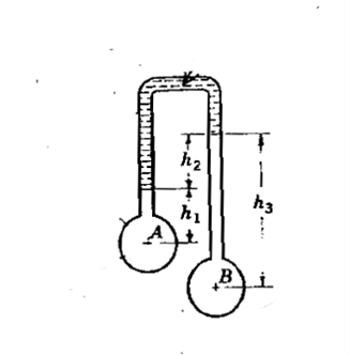

In [61]:
from PIL import Image
img = Image.open(r"figures/49.png")
base_width = 350  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

**Question 11 (a)**

 ```{dropdown} Hint

Express the pressure difference AB in terms of pressures 1, 2, and 3.
 
 ```

**Solution**

 ```{dropdown} Show code cell outputs
 The difference between the pressures at A an B can be expressed as follows:  
 
 $$dp_{AB}=-p_3+p_1+p_2$$  
 
 Expressing each pressure with the hydrostatic pressure equation, we have: 
 
 $$p_1=\rho_{water} \cdot g \cdot h_1$$
 $$p_2=\rho_{oil} \cdot g \cdot h_2$$  
 $$p_3=\rho_{water} \cdot g \cdot  h_3$$  
 
 We can reeplace the pressure equations to obtain the following:  
 
 $$dp_{AB}=-\rho_{water} \cdot g  \cdot h_3+\rho_{water} \cdot g \cdot h_1+\rho_{oil} \cdot g \cdot h_2$$ 
 
 ```

In [62]:
%%render long 2

s_oil=0.8
h_1=0.3 #m
h_2=0.2 #m
h_3=0.6 #m

rho_oil= s_oil*rho_water #kg/m3
dp_AB= -rho_water*g*h_3+rho_oil*g*h_2+rho_water*g*h_1 #Pa
dp_AB_= dp_AB/1000 #kPa

<IPython.core.display.Latex object>

**Question (b)**

```{dropdown} Hint
Convert Hg height to water height
```

**Solution**

```{dropdown} Show code cell outputs
Pressure at A is equal to the pressure at B plus the pressure difference:  

$$p_A=p_B+dp_{AB}$$  
$$p_A=p_B+(-\rho_{water} \cdot g \cdot h_3+\rho_{water} \cdot g \cdot h_1+\rho_{oil} \cdot g \cdot h_2)$$    

Now, to convert Hg height to water height, first, we equal the pressure of water to the pressure of Mercury:  

$$ p_{Hg}=\rho_{Hg} \cdot g \cdot h_{Hg}$$  
$$p_{water}=\rho_{water} \cdot g \cdot h_{water}$$  
$$p_{water}=p_{Hg}$$  
$$\rho_{water} \cdot g \cdot h_{water}=\rho_{Hg}  \cdot g \cdot h_{Hg}$$    

Then, solving for $h_{water}$, we obtain:  

$$h_{water}=\frac{\rho_{Hg} \cdot g \cdot h_{Hg}}{\rho_{water} \cdot g}$$

$$h_{water}=\frac{\rho_{Hg} \cdot  h_{Hg}}{\rho_{water} }$$  

```

In [63]:
%%render long 2

p_B=50000 #Pa
h_Hg= 0.730 #m Hg
rho_Hg_=13600 #kg/m3

p_A= p_B-rho_water*g*h_3+rho_water*g*h_1+rho_oil*g*h_2 #Pa
h_water= (rho_Hg_/rho_water)*h_Hg #m
p_A_abs= p_A/(rho_water*g)+h_water #m abs

<IPython.core.display.Latex object>

---
#### Question 12 (***)[R]

Calculate the pressure at A in the figure below. Work from basic principles. Assume ρ<sub>Hg</sub> = 13550 kg/m<sup>3</sup>.

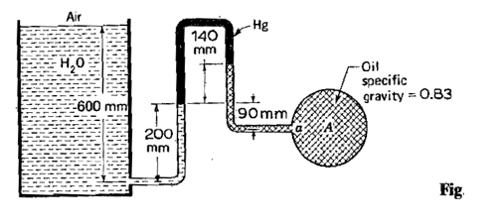

In [64]:
from PIL import Image
img = Image.open(r"figures/50.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

 $-12.8 \; kPa$

```

```{dropdown} Hint

Consider that the same fluid at the same height has the same pressure.

```

**Solution**

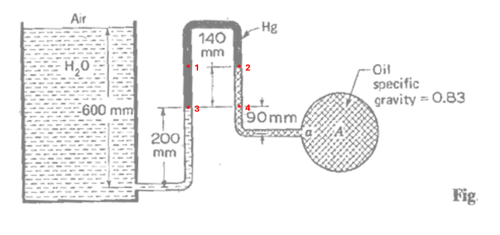

In [65]:
from PIL import Image
img = Image.open(r"figures/50s.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Show code cell outputs
Considering that the same fluid at the same height has the same pressure, the following point has equal pressures $p_1=p_2$

Also, using the hydrostatic pressure equation, we can express the pressures $p_1$, $p_2$, $p_3$, and $p_4$ as:  

$$
p_1= p_3-\rho_{Hg}\cdot g \cdot h_{Hg}\\
$$

$$
p_2= p_4- \rho_{oil} \cdot g \cdot h_{oil Hg}\\
$$

$$
p_3= \rho_{water} \cdot g \cdot h_{water tank}-\rho_{water} \cdot g \cdot h_{water}\\
$$

$$
p_4= p_A- \rho_{oil} \cdot g \cdot h_{oil}\\
$$

Using the previous equations, $p_A$ can be calculated as:

$$
p_A=p_4+\rho_{oil} \cdot g \cdot h_{oil}\\
=p_2+\rho_{oil} \cdot g \cdot h_{oil Hg}+\rho_{oil} \cdot g \cdot h_{oil}\\
=p_1+\rho_{oil} \cdot g \cdot h_{oil Hg}+\rho_{oil} \cdot g \cdot h_{oil}\\
=p_3-\rho_{Hg}\cdot g \cdot h_{Hg}+\rho_{oil} \cdot g \cdot h_{oil Hg}+\rho_{oil} \cdot g \cdot h_{oil}\\
=\rho_{water} \cdot g \cdot h_{water tank}-\rho_{water} \cdot g \cdot h_{water}-\rho_{Hg}\cdot g \cdot h_{Hg}+\rho_{oil} \cdot g \cdot h_{oil Hg}+\rho_{oil} \cdot g \cdot h_{oil}\\
$$
```

In [66]:
%%render long 3

rho_Hg_= 13550 #kg/m3
h_water_tank=600 #mm 
h_water=200 #mm 
h_Hg= 140 #mm 
h_oil=90 #mm 
s_oil= 0.83 

rho_oil=s_oil*rho_water # kg/m3
p_A= rho_water*g*(h_water_tank-h_water)/1000-rho_Hg_*g*h_Hg/1000 +rho_oil*g*(h_oil+h_Hg)/1000 #Pa
p_A_abs= p_A+ p_atm #Pa

<IPython.core.display.Latex object>

---
#### Question 13 (**)

Both gauges in the figure below are calibrated to measure absolute pressure. The gauge A in the figure below reads 290 kPa abs. What is the height h of water? What does gauge B read? Assume ρ<sub>Hg</sub> = 13600 kg/m<sup>3</sup>.

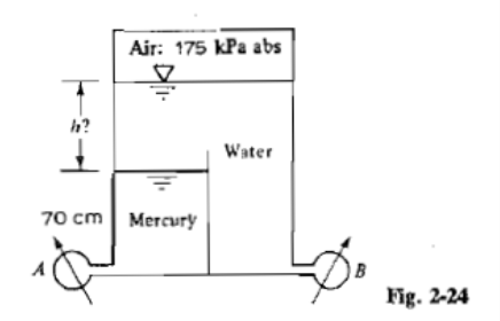

In [67]:
from PIL import Image
img = Image.open(r"figures/51.png")
base_width = 500  # Change this to your desired width
w_percent = base_width / float(img.size[0])
h_size = int(float(img.size[1]) * w_percent)
resized_img = img.resize((base_width, h_size))
resized_img

```{dropdown} Answer

$2.23 \; m \;; 204 \; kPa abs$

```

```{dropdown} Hint
Use the hydrostatic pressure equation:

$$
p= \rho_{fluid} \cdot g \cdot h\\
$$

```

**Solution**

```{dropdown} Show code cell outputs
With the hydrostatic pressure equation we have that $p_A$ is:  

$$p_A=\rho_{Hg} \cdot g \cdot h_1+\rho_{water} \cdot g  \cdot h +p_{air}$$  

Using this equation we can solve $h$:

$$h=\frac{p_A-(\rho_{Hg} \cdot g \cdot h_1)-p_{air}}{\rho_{water} \cdot g}$$  

Then, the pressure at B can be calculated as:  

$$p_B=p_{air}+\rho_{water} \cdot g \cdot (h+h_1)$$  

```

In [68]:
%%render long 2
p_A=290000 #Pa
rho_Hg_=13600 #kg/m3
h_1=0.7 #m
p_air=175000 #Pa abs

h= (p_A-rho_Hg_*g*h_1-p_air)/(rho_water*g) #m
p_B= p_air+rho_water*g*(h_1+h) #Pa
p_B_= p_B/1000 #kPa

<IPython.core.display.Latex object>